# Exploratory Data Analysis: Welltory COVID-19 Wearables

**Dataset:** [Welltory COVID-19 and Wearables Open Data Research](https://github.com/Welltory/hrv-covid19)

**Feature dictionary:** [datatypes.md](https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md)



## Motivation
Most of the time I love my Whoop data. Sometimes I hate it though. I have come to realize my recovery score mostly correlates with my HRV during sleep. Which also on its own is related to my resting heart rate and other markers.
When I am sick for example, I usually have much a lower sleep HRV average than I would usually have. Hence a low recovery is expected for me on a sick day, even if I sleep for more hours than usual. So why not look into that! Booyakasha!


## Data context and sampling

This is Welltory's 2020 open COVID-19 wearable study, not a lab trial. App users who reported COVID tracked HRV, symptoms, and (sometimes) watch data at home. HRV comes from a Bluetooth chest strap or phone-camera PPG. Sampling is volunteer / convenience: you had to use Welltory, own a phone, and keep measuring while sick, so it is biased toward health-app users and is not a random population sample.

Welltory anonymized people as `user_code` and published CSVs on GitHub under a Creative Commons licence. Lineage: Welltory app (2020) → anonymized CSV dump → this notebook loads them over HTTPS.

Tables used: `participants.csv` (185 people), `hrv_measurements.csv` (~3,245 HRV takes), `surveys.csv`.

## What the features mean

| Column | Meaning |
|---|---|
| `user_code` | Anonymized participant id (join key) |
| `bpm` | Heart rate during the HRV take (beats per minute) |
| `rmssd` | Short-term HRV: root mean square of successive RR differences (ms). Higher ≈ more beat-to-beat variation / parasympathetic activity |
| `sdnn`, `pnn50` | Other HRV summaries of the same beat list |
| `how_feel`, `how_mood`, `how_sleep` | In-app self-ratings at measurement time |
| `symptoms_onset` | Self-reported date symptoms started |
| `tags` | Free-text activity/illness tags (e.g. COVID-19) |
| Survey `S_COVID_*` | Symptom items; `value` is a coded answer (`scales_description.csv`) |
| `rr_data` | Raw RR-interval string. Closest thing to the raw signal; dropped for tabular EDA |

This notebook focuses on `rmssd` and `bpm` because they are complete here and are the usual COVID/HRV markers. `rmssd` is a **summary**, not the raw PPG waveform.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

BASE = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data/"

participants = pd.read_csv(BASE + "participants.csv")
hrv = pd.read_csv(BASE + "hrv_measurements.csv")
surveys = pd.read_csv(BASE + "surveys.csv")
scales = pd.read_csv(BASE + "scales_description.csv")

print("participants", participants.shape)
print("hrv_measurements", hrv.shape)
print("surveys", surveys.shape)
print("scales", scales.shape)


participants (185, 8)
hrv_measurements (3245, 22)
surveys (2259, 5)
scales (148, 4)


In [12]:
# Analysis frame: one row per HRV measurement
df = hrv.drop(columns=["rr_data"]).merge(participants, on="user_code", how="left")
df["measurement_datetime"] = pd.to_datetime(df["measurement_datetime"], errors="coerce")
df["measure_date"] = df["measurement_datetime"].dt.date
df["symptoms_onset"] = pd.to_datetime(df["symptoms_onset"], errors="coerce")

print(df.head())


    user_code     rr_code measurement_datetime time_of_day  bpm  meanrr  \
0  007b8190cf  10489a6aea  2020-04-21 21:23:08     morning   75  795.90   
1  007b8190cf  9610d4d4dc  2020-04-26 11:19:25     morning   70  858.00   
2  013f6d3e5b  f3de056155  2020-05-15 04:14:21       night   83  724.10   
3  013f6d3e5b  b04489e32f  2020-05-19 03:06:02       night   75  802.64   
4  01bad5a519  ac52c706c6  2019-12-31 09:07:43     morning   78  768.07   

   mxdmn    sdnn   rmssd  pnn50   mode   amo     lf      hf     vlf   lfhf  \
0   0.12  45.802  54.174  15.15  0.775  53.0  508.0  1076.0   267.0  0.472   
1   0.11  32.889  33.022  16.16  0.875  54.0  409.0   310.0   176.0  1.319   
2   0.17  54.811  65.987  17.17  0.725  46.0  432.0   881.0   194.0  0.490   
3   0.20  72.223  70.039  22.22  0.825  43.0  814.0  1487.0  1719.0  0.547   
4   0.10  29.650  21.196   4.04  0.775  56.0  489.0   128.0    96.0  3.820   

   total_power  how_feel  how_mood  how_sleep  \
0       1851.0         0       

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [3]:
print("Data Structure")
print("---------------")
print(f"Dimensions: {df.shape}")
print(f"Unique users: {df['user_code'].nunique()}")
print(f"Date range: {df['measurement_datetime'].min()} → {df['measurement_datetime'].max()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum().sort_values(ascending=False)}")
print(f"\nMissing fraction:\n{df.isnull().mean().sort_values(ascending=False).round(3)}")


Data Structure
---------------
Dimensions: (3245, 29)
Unique users: 185
Date range: 2019-12-31 06:08:29 → 2020-06-19 11:40:13

Data Types:
user_code                       object
rr_code                         object
measurement_datetime    datetime64[ns]
time_of_day                     object
bpm                              int64
meanrr                         float64
mxdmn                          float64
sdnn                           float64
rmssd                          float64
pnn50                          float64
mode                           float64
amo                            float64
lf                             float64
hf                             float64
vlf                            float64
lfhf                           float64
total_power                    float64
how_feel                         int64
how_mood                         int64
how_sleep                      float64
tags                            object
gender                          object
age

## Interpretation

There are on the order of 3,245 HRV measurements from 185 users. Some people measured many times while others barely at all.

Core HRV numbers (`bpm`, `rmssd`, `sdnn`, …) are fully populated. how_sleep` is missing ~55% and `tags` ~32%. City/country/`symptoms_onset` missing comes from the participant table (onset is missing for ~20% of people).

`how_feel` / `how_mood` use sentinels like `-2,-1,0,1,2`


## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [13]:
num_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "lfhf", "total_power"]

print("Descriptive Statistics")
print("----------------------")
print("Central tendency (mean / median):")
print(df[num_cols].agg(["mean", "median"]).T.round(3))
print("\nDispersion:")
print(df[num_cols].agg(["min", "max", "std", "var"]).T.round(3))
print("\nSkewness / kurtosis:")
print(pd.DataFrame({"skew": df[num_cols].skew(), "kurtosis": df[num_cols].kurtosis()}).round(3))
print("\nFull describe:")
print(df[num_cols].describe().T.round(3))


Descriptive Statistics
----------------------
Central tendency (mean / median):
                 mean    median
bpm            73.258    72.000
meanrr        839.600   829.100
sdnn           52.489    46.919
rmssd          52.814    42.869
pnn50          20.616    16.160
lf            927.038   423.000
hf           1125.041   380.000
lfhf            2.398     0.862
total_power  2630.309  1387.000

Dispersion:
                 min        max       std           var
bpm           44.000    125.000    12.201  1.488670e+02
meanrr       477.730   1346.740   137.420  1.888436e+04
sdnn           9.515    206.631    29.370  8.625680e+02
rmssd          6.340    310.800    39.353  1.548675e+03
pnn50          0.000     91.920    18.588  3.455200e+02
lf             2.000  15522.000  1455.424  2.118259e+06
hf             4.000  33490.000  2490.540  6.202792e+06
lfhf           0.032    105.625     5.751  3.307100e+01
total_power   44.000  41118.000  3912.247  1.530568e+07

Skewness / kurtosis:
     

## Interpretation

`bpm` is roughly centered in the low-70s (plausible resting/seated HR) with a right tail up to 125. **`rmssd` is right-skewed** (median ~43, mean ~53, max ~311). That is typical of HRV: most people cluster at moderate values; a few very high readings may be real athletes *or* PPG artifacts.

I have seen on Whoop community tab some crazy HRV values and so on. Turkish voleyball superstar Melissa Vargas for example shares her stats for example, and let me just say there is a reason why she's my hero.

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [14]:
print("Data Quality")
print("------------")
print("Full-row duplicates:", df.duplicated().sum())
print("Duplicate rr_code:", df["rr_code"].duplicated().sum())
print("Duplicate user+timestamp:", df.duplicated(subset=["user_code", "measurement_datetime"]).sum())

print("\nImplausible BPM (<40 or >180):", ((df["bpm"] < 40) | (df["bpm"] > 180)).sum())
print("Very high RMSSD (>150 ms):", (df["rmssd"] > 150).sum())
print("Negative RMSSD/SDNN:", ((df["rmssd"] < 0) | (df["sdnn"] < 0)).sum())

# Known inconsistency from a sample row: time_of_day vs clock hour
df["hour"] = df["measurement_datetime"].dt.hour
print("\nTime-of-day bucket vs clock hour (crosstab, row %):")
print(pd.crosstab(df["time_of_day"], pd.cut(df["hour"], [-1, 5, 11, 17, 23], labels=["night","morning","day","evening"]), normalize="index").round(2))

print("\nUsers in HRV missing from participants:", df["user_code"].isna().sum())
print("Survey users not in participants:", (~surveys["user_code"].isin(participants["user_code"])).sum())
print("HRV users with zero surveys:", (~df["user_code"].isin(surveys["user_code"])).sum())


Data Quality
------------
Full-row duplicates: 0
Duplicate rr_code: 0
Duplicate user+timestamp: 0

Implausible BPM (<40 or >180): 0
Very high RMSSD (>150 ms): 118
Negative RMSSD/SDNN: 0

Time-of-day bucket vs clock hour (crosstab, row %):
hour         night  morning   day  evening
time_of_day                               
day           0.00     0.03  0.78     0.19
evening       0.13     0.00  0.03     0.85
morning       0.04     0.95  0.01     0.00
night         0.29     0.00  0.00     0.71

Users in HRV missing from participants: 0
Survey users not in participants: 0
HRV users with zero surveys: 390


## Interpretation

No full-row duplicates and `rr_code` looks unique so no need to drop rows for duplication.

Domain checks: adult BPM 44–125 is plausible (no 0s or 220s). RMSSD > 150 ms is uncommon at rest and can be noise or elite athlete physiology; will flag those rather than auto-delete and investigate.

Consistency issue: `time_of_day` does not always match the timestamp hour (a 21:23 take labeled `morning` appears in the raw dump). Rationale: trust `measurement_datetime` over the bucket if they conflict.

Integrity: every HRV `user_code` joins to `participants`. Surveys cover only ~111 of 185 users which means we have incomplete outcomes, not a broken key.


## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?


Variable Relationships
              bpm  meanrr  sdnn  rmssd  pnn50    lf    hf  lfhf  total_power
bpm          1.00   -0.98 -0.34  -0.21  -0.41 -0.17 -0.11 -0.00        -0.18
meanrr      -0.98    1.00  0.35   0.23   0.45  0.18  0.13 -0.02         0.20
sdnn        -0.34    0.35  1.00   0.91   0.81  0.74  0.77 -0.02         0.88
rmssd       -0.21    0.23  0.91   1.00   0.84  0.63  0.86 -0.16         0.84
pnn50       -0.41    0.45  0.81   0.84   1.00  0.56  0.73 -0.18         0.74
lf          -0.17    0.18  0.74   0.63   0.56  1.00  0.60  0.16         0.83
hf          -0.11    0.13  0.77   0.86   0.73  0.60  1.00 -0.12         0.91
lfhf        -0.00   -0.02 -0.02  -0.16  -0.18  0.16 -0.12  1.00        -0.01
total_power -0.18    0.20  0.88   0.84   0.74  0.83  0.91 -0.01         1.00


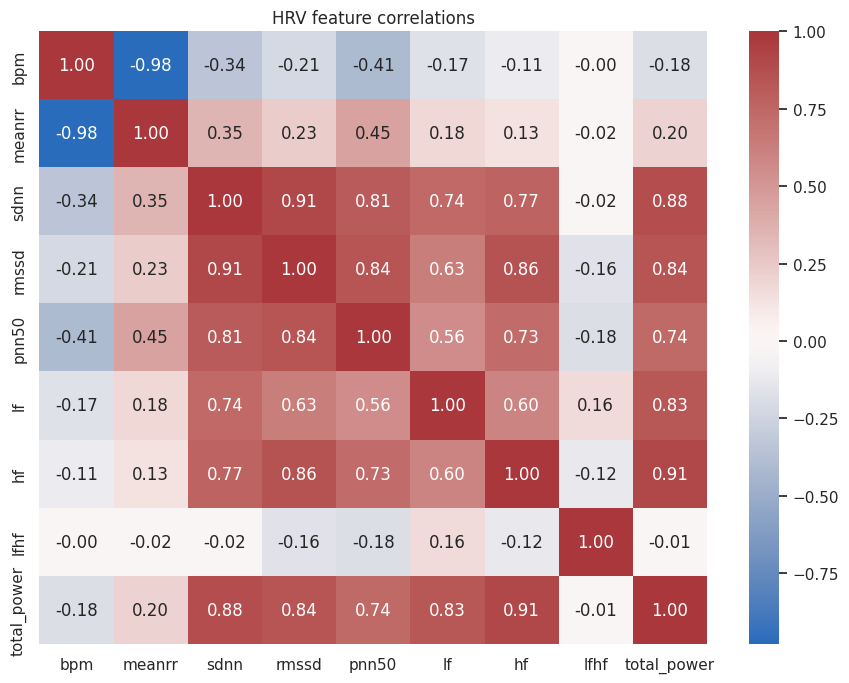


RMSSD by gender:
         count   mean    std   min    25%    50%    75%    max
gender                                                        
f       2060.0  56.70  45.13  6.34  29.98  42.73  64.88  277.1
m       1185.0  46.05  25.08  7.56  26.74  43.89  59.13  310.8

RMSSD by time_of_day:
time_of_day
evening    35.573
day        39.456
night      45.106
morning    48.478
Name: rmssd, dtype: float64

BPM vs how_feel:
how_feel
-2    75.5
-1    73.0
 0    72.0
 1    70.0
 2    74.0
Name: bpm, dtype: float64


In [6]:
print("Variable Relationships")
corr = df[num_cols].corr()
print(corr.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("HRV feature correlations")
plt.tight_layout()
plt.show()

print("\nRMSSD by gender:")
print(df.groupby("gender")["rmssd"].describe().round(2))
print("\nRMSSD by time_of_day:")
print(df.groupby("time_of_day")["rmssd"].median().sort_values())
print("\nBPM vs how_feel:")
print(df.groupby("how_feel")["bpm"].median())


## Interpretation

`bpm` and `meanrr` are almost perfectly inverse (RR is 60000/bpm) so they are literally the same information. Would not make sense to feed both into models given they are interacting, but literally connected formulaicly.

`rmssd` tracks `pnn50` and (to a point) `sdnn` because they are related HRV summaries. `lfhf` is weakly related to time-domain HRV.



## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


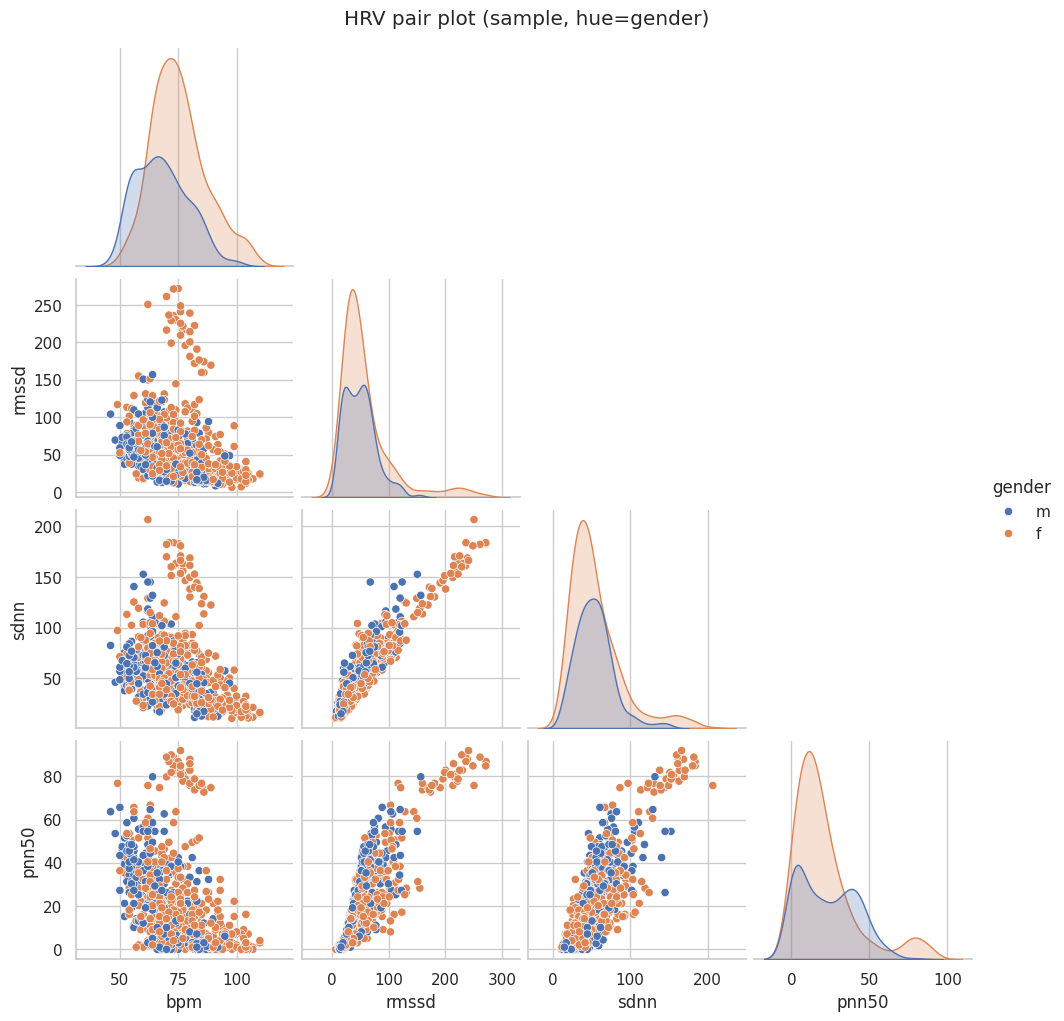

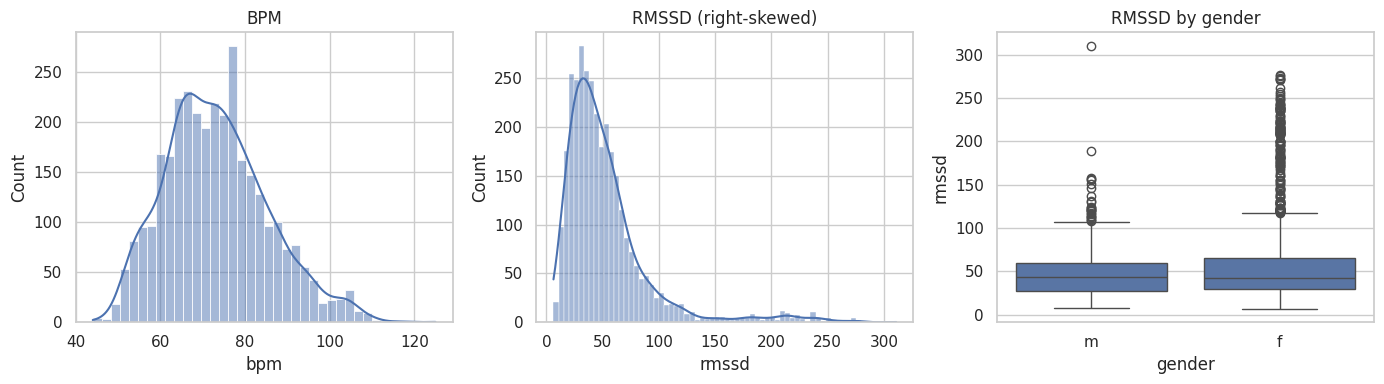

In [15]:
# Data Visualization
viz = df.sample(n=min(len(df), 800), random_state=0)

sns.pairplot(viz, vars=["bpm", "rmssd", "sdnn", "pnn50"], hue="gender", corner=True)
plt.suptitle("HRV pair plot (sample, hue=gender)", y=1.02)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df["bpm"], kde=True, ax=axes[0])
axes[0].set_title("BPM")
sns.histplot(df["rmssd"], kde=True, ax=axes[1])
axes[1].set_title("RMSSD (right-skewed)")
sns.boxplot(data=df, x="gender", y="rmssd", ax=axes[2], showfliers=True)
axes[2].set_title("RMSSD by gender")
plt.tight_layout()
plt.show()


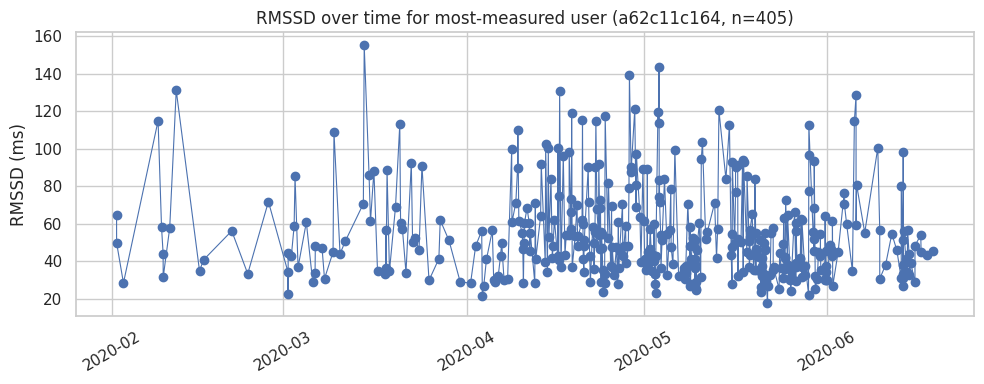

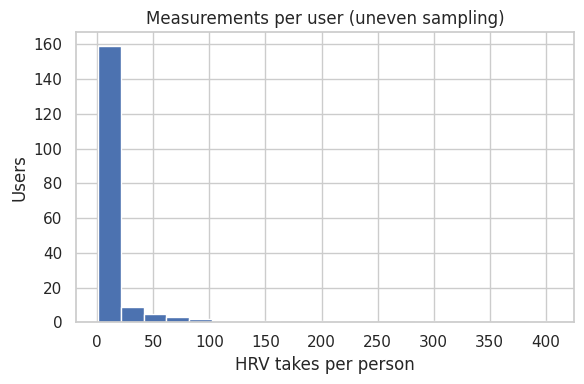

In [16]:
# Longitudinal view
user_counts = df["user_code"].value_counts()
uid = user_counts.index[0]
one = df[df["user_code"] == uid].sort_values("measurement_datetime")

plt.figure(figsize=(10, 4))
plt.plot(one["measurement_datetime"], one["rmssd"], marker="o", linewidth=0.8)
plt.title(f"RMSSD over time for most-measured user ({uid}, n={len(one)})")
plt.ylabel("RMSSD (ms)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
user_counts.hist(bins=20)
plt.title("Measurements per user (uneven sampling)")
plt.xlabel("HRV takes per person")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


## Interpretation

**Histograms:** BPM is unimodal; RMSSD is skewed with a long right tail.

**Box plots:** gender differences are secondary to *within-person* spread. Outlier dots on RMSSD are the flagged candidates (>150).

**Pair plot:** BPM vs RMSSD often slopes down a bit (higher HR, lower HRV), which matches physiology, with lots of scatter.

**Time series + per-user histogram:** A few users dominate the row count. Any "COVID vs healthy" comparison that ignores user id will be biased toward frequent measurers. They also make it seem like there are clusters but they belong to same users on occasion.


## Handling missing values, duplicates, and outliers

**Duplicates.** 0 full-row duplicates. No drop.

**Missing values.**
- Do **not** mean-impute `how_sleep` or `tags`. Sleep rating is missing half the time; filling 0 would invent "neutral sleep."
- Do **not** impute `symptoms_onset`. Missing onset ≠ "never sick"; it is "didn't report."
- Drop `tags` from modeling features (free text, 32% missing). Keep the column for EDA of people who tagged "COVID-19".
- Rationale: missingness is **MNAR/MAR** (sick or busy people skip fields), not MCAR.

**Outliers.**
- BPM already sits in a believable band.
- RMSSD: winsorize / cap at the 99th percentile **for visualization and z-scores**, and keep a boolean `rmssd_artifact_flag` instead of deleting. Deleting would drop the interesting sick-day spikes we care about if they are real.


In [9]:
clean = df.copy()

# Missing: explicit flags, no imputation of symptoms/sleep
clean["how_sleep_missing"] = clean["how_sleep"].isna().astype(int)
clean["onset_missing"] = clean["symptoms_onset"].isna().astype(int)

# Outliers: flag + winsorized copy for plots/models that hate tails
q99 = clean["rmssd"].quantile(0.99)
clean["rmssd_artifact_flag"] = (clean["rmssd"] > 150).astype(int)
clean["rmssd_winsor"] = clean["rmssd"].clip(upper=q99)

print("RMSSD artifact flags:", clean["rmssd_artifact_flag"].sum(), f"(cap at 99th pct = {q99:.1f} ms)")
print("how_sleep missing flag rate:", clean["how_sleep_missing"].mean().round(3))
print("onset missing (row rate):", clean["onset_missing"].mean().round(3))
print("Rows dropped for duplicates/missing HRV: 0 (none needed)")


RMSSD artifact flags: 118 (cap at 99th pct = 226.6 ms)
how_sleep missing flag rate: 0.548
onset missing (row rate): 0.132
Rows dropped for duplicates/missing HRV: 0 (none needed)


## Data transformation

Parse datetimes. Log-transform skewed RMSSD so histograms and correlations are not owned by the tail. Scale

**Rationale for log1p(rmssd):** skewness was clearly positive; log is monotonic so rank comparisons survive.


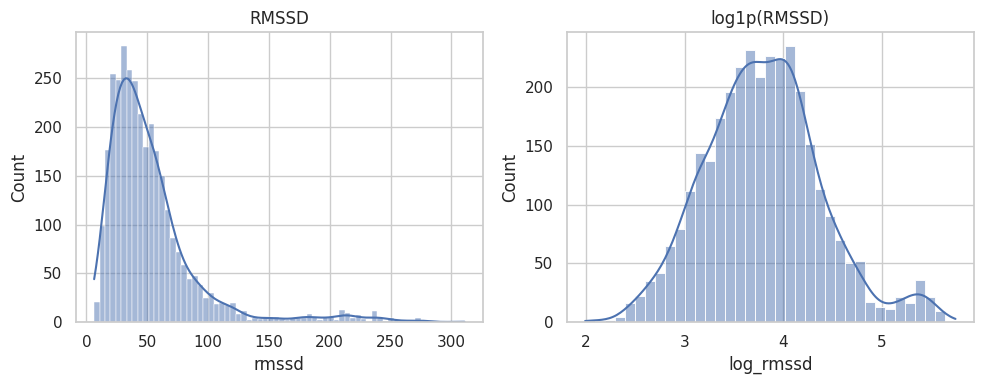

In [10]:
clean["log_rmssd"] = np.log1p(clean["rmssd"])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(clean["rmssd"], ax=ax[0], kde=True)
ax[0].set_title("RMSSD")
sns.histplot(clean["log_rmssd"], ax=ax[1], kde=True)
ax[1].set_title("log1p(RMSSD)")
plt.tight_layout()
plt.show()


## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?


          rmssd  rmssd_z_user  days_from_onset  tag_covid
count  3245.000      3191.000         2816.000   3245.000
mean     52.814         0.000          517.528      0.216
std      39.353         0.979         2705.174      0.412
min       6.340        -2.994         -726.000      0.000
25%      28.985        -0.701           -6.000      0.000
50%      42.869        -0.176           22.000      0.000
75%      62.485         0.529           44.000      0.000
max     310.800         5.775        19465.000      1.000


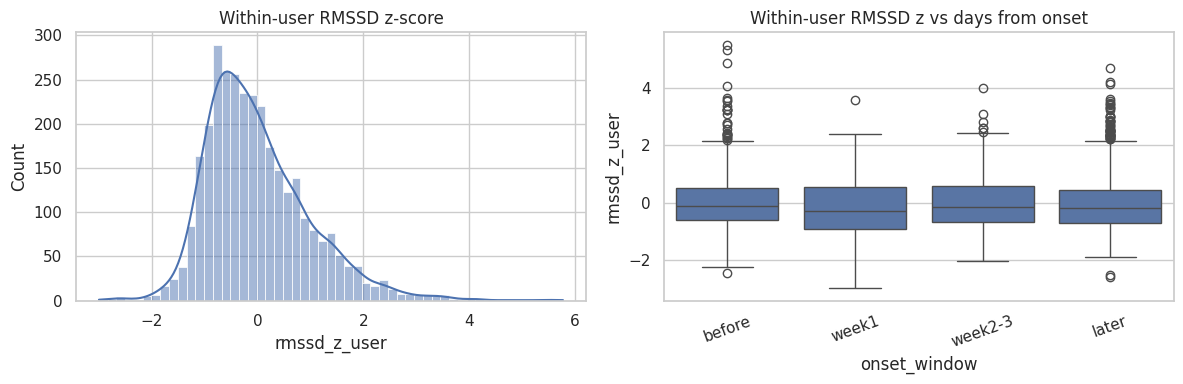

In [11]:
# Feature engineering
# 1) Within-user RMSSD z-score: "is today low for THIS person?"
#    Rationale: HRV baselines differ hugely across people. COVID papers on this
#    dataset care about intra-individual change, not beating a global cutoff.
g = clean.groupby("user_code")["rmssd"]
clean["rmssd_z_user"] = (clean["rmssd"] - g.transform("mean")) / g.transform("std").replace(0, np.nan)

# 2) Days since reported symptom onset (negative = before onset)
clean["days_from_onset"] = (clean["measurement_datetime"] - clean["symptoms_onset"]).dt.days

# 3) COVID-related tag from the free-text tags field
clean["tag_covid"] = clean["tags"].fillna("").str.contains("COVID", case=False).astype(int)

print(clean[["rmssd", "rmssd_z_user", "days_from_onset", "tag_covid"]].describe().round(3))

onset = clean.dropna(subset=["days_from_onset"]).copy()
onset["onset_window"] = pd.cut(
    onset["days_from_onset"],
    [-np.inf, -1, 7, 21, np.inf],
    labels=["before", "week1", "week2-3", "later"],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean["rmssd_z_user"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Within-user RMSSD z-score")
sns.boxplot(data=onset, x="onset_window", y="rmssd_z_user", ax=axes[1])
axes[1].set_title("Within-user RMSSD z vs days from onset")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Interpretation

**New feature `rmssd_z_user`:** a take of 30 ms is "low" for someone whose baseline is 80 and "normal" for someone whose baseline is 25. The z-score is the thing you'd actually feed a "getting sick?" detector. So left tail is potentially those experiencing some form of sickness or unusual sleep discomfort. Could be things like alcohol or controlled substance use as well.

**`days_from_onset`:** only defined when the participant filled `symptoms_onset`. Missing onset is not filled with 0.

Boxplots vs onset window are hypothesis-generating only (volunteer timing, no lab-confirmed infection date for everyone).
This table doesn’t show a clean average drop after reported onset despite my intuitions.


## Data quality assessment

**Profiling.** 185 users, 3,245 HRV rows, 8 participant fields, 22 HRV fields (minus `rr_data`). Mix of numeric HRV, Likert self-reports, free-text tags, and coded surveys (58 scales).

**Completeness.** HRV core metrics are complete. Sleep rating, tags, city, symptom onset, and most wearable columns are not. Surveys exist for only ~60% of users. Completeness is differential: frequent Welltory users look "complete"; others look empty.

**Accuracy.** Phone PPG HRV is an estimate, not a Holter ECG. Self-reported COVID/symptoms can be wrong (no test required for every row). Treat as noisy labels.

**Consistency.** `time_of_day` vs clock time disagrees. `bpm` and `meanrr` are redundant. Wearable daily `pulse_average` may not match the same morning's HRV `bpm` (different device, different moment).

**Integrity.** HRV and participant keys line up. Surveys are a subset. No orphan `user_code`s in HRV. `rr_code` is unique.

**Lineage and provenance.** Source = Welltory app users, 2020, anonymized, published at `github.com/Welltory/hrv-covid19`. We pull CSVs over HTTPS at runtime. We do not modify the upstream files; cleaning happens only in this notebook. Downstream use should cite Welltory and keep the volunteer-sample caveat.

**Rationale summary.** Keep all HRV rows; flag artifacts; don't invent sleep or onset; prefer datetime over `time_of_day`; analyze change within user.


# Interpretation for Machine Learning

**Dimensions.** 3k rows / 185 clusters. Mixed-effects or user-level aggregates beat a naive sklearn split. Random row-wise train/test **leaks** the same person into both sides.

**Data types.** Encode `gender` / `age_range`; keep `user_code` as a grouping key, not a one-hot of 185 levels unless you have a reason.

**Missing values.** Use missingness flags (`how_sleep_missing`, `onset_missing`). Avoid median fill on MNAR survey fields.

**Descriptive stats / skew.** Log RMSSD or use tree models that don't assume normality.

**Quality / outliers.** Keep `rmssd_artifact_flag` as a feature; don't silently drop sick-day extremes.

**Relationships.** Drop `meanrr` if `bpm` is present. Don't stack `rmssd`, `pnn50`, and `sdnn` as if they were independent without checking VIF / feature importance.

**Visuals.** The per-user histogram says "weight users equally" or "model as panel data."

**Feature engineering.** `rmssd_z_user` is the main derived signal. Compute it with **training-user stats only** in a real pipeline (here we z-score on all data for EDA).
